<a href="https://colab.research.google.com/github/mariia-m-analytics/sales-analytics/blob/main/final_progect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")
# Example of changing work folder
%cd /content/drive/MyDrive/python_files/
# import CSV file
# Розпакувати архів у папку 'data'
!unzip -o -q dataset.zip -d ./data

# Тепер читайте файли за звичайним шляхом
df_countries = pd.read_csv("./data/13. Final project/countries.csv")
df_products = pd.read_csv("./data/13. Final project/products.csv")
df_events = pd.read_csv("./data/13. Final project/events.csv")

Mounted at /content/drive
/content/drive/MyDrive/python_files


1. Перегляд структури:

In [ ]:
print("--- Інформація про таблицю подій ---")
df_events.info()

# Подивитись на перші 5 рядків кожної таблиці
display(df_events.head())
display(df_products.head())
display(df_countries.head())

--- Інформація про таблицю подій ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


ключові поля, що поєднують три таблиці:
Таблиця df_events: колонка Product ID - Таблиця df_products: колонка id
Таблиця df_events: колонка Country Code - аблиця df_countries: колонка alpha-3

2. Очищення даних:

In [ ]:
# Рахуємо пропуски у відсотках для головної таблиці
missing_data = df_events.isna().mean() * 100
print(missing_data[missing_data > 0])

Country Code    6.165414
Units Sold      0.150376
dtype: float64


In [ ]:
# 1. Видаляємо рядки, де пропущено кількість проданих одиниць (Units Sold)
df_events = df_events.dropna(subset=['Units Sold'])

# 2. Заповнюємо пропуски в Country Code значенням 'Unknown'
df_events['Country Code'] = df_events['Country Code'].fillna('Unknown')

# 3. Перевіряємо результат
print("Залишилося пропусків:")
print(df_events.isna().sum())

Залишилося пропусків:
Order ID          0
Order Date        0
Ship Date         0
Order Priority    0
Country Code      0
Product ID        0
Sales Channel     0
Units Sold        0
Unit Price        0
Unit Cost         0
dtype: int64


Колонка Units Sold - 0.15% пропусків. Це дуже мала частка даних, найкращим рішенням буде видалити ці рядки.
Колонка Country Code - 6.16% пропусків. Це суттєва частка. Найкраще рішення заповнити пропуски значенням 'Unknown'

In [ ]:
# Перетворення у формат datetime
df_events['Order Date'] = pd.to_datetime(df_events['Order Date'])
df_events['Ship Date'] = pd.to_datetime(df_events['Ship Date'])

# Перевірка результату
print(df_events.dtypes)

Order ID                   int64
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Order Priority            object
Country Code              object
Product ID                 int64
Sales Channel             object
Units Sold               float64
Unit Price               float64
Unit Cost                float64
dtype: object


In [ ]:
# Очищаємо таблицю товарів
df_products['item_type'] = df_products['item_type'].str.strip().str.capitalize()

# Очищаємо таблицю країн (назви та коди)
df_countries['name'] = df_countries['name'].str.strip()
df_countries['alpha-3'] = df_countries['alpha-3'].str.strip().str.upper()

# Очищаємо головну таблицю продажів
df_events['Country Code'] = df_events['Country Code'].str.strip().str.upper()
df_events['Sales Channel'] = df_events['Sales Channel'].str.strip().str.capitalize()

In [ ]:
# Рахуємо кількість дублікатів у таблиці подій
print(f"Кількість дублікатів у df_events: {df_events.duplicated().sum()}")

# Видаляємо їх
df_events = df_events.drop_duplicates()

Кількість дублікатів у df_events: 0


In [ ]:
# Дивимось статистику: мін, макс, середнє
display(df_events.describe())

# Приклад перевірки аномалій у цінах
# Якщо Unit Price <= 0, це аномалія
anomalies = df_events[df_events['Unit Price'] <= 0]
print(f"Знайдено аномальних цін: {len(anomalies)}")

,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


Знайдено аномальних цін: 0


За результатами аналізу, аномальних значень у колонках ціни, собівартості та кількості продажів не виявлено. Всі значення знаходяться в межах реалістичних бізнес-показників.

3.  Аналіз та візуалізація даних:

In [ ]:
# 1. Об'єднання
df_full = df_events.merge(df_products, left_on='Product ID', right_on='id', how='left')
df_full = df_full.merge(df_countries, left_on='Country Code', right_on='alpha-3', how='left')

# 2. Видаляємо дубльовані колонки ID та технічні коди, які не потрібні для візуалізації
df_full = df_full.drop(columns=['id', 'alpha-2', 'alpha-3'])

# 3. Розрахункові метрики
df_full['Total Revenue'] = df_full['Units Sold'] * df_full['Unit Price']
df_full['Total Cost'] = df_full['Units Sold'] * df_full['Unit Cost']
df_full['Total Profit'] = df_full['Total Revenue'] - df_full['Total Cost']
df_full['Delivery Days'] = (df_full['Ship Date'] - df_full['Order Date']).dt.days

# 4. Додаємо день тижня
df_full['Order Day'] = df_full['Order Date'].dt.day_name()

In [ ]:
print(f"Загальна кількість замовлень: {df_full['Order ID'].nunique()}")
print(f"Загальний прибуток: ${df_full['Total Profit'].sum():,.2f}")
print(f"Кількість охоплених країн: {df_full['name'].nunique()}")
print(f"Середній чек: ${df_full['Total Revenue'].mean():,.2f}")
print(f"Середній термін доставки: {df_full['Delivery Days'].mean():.1f} дн.")

Загальна кількість замовлень: 1328
Загальний прибуток: $501,434,459.00
Кількість охоплених країн: 45
Середній чек: $1,281,723.95
Середній термін доставки: 24.8 дн.


/tmp/ipykernel_8145/1257386096.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


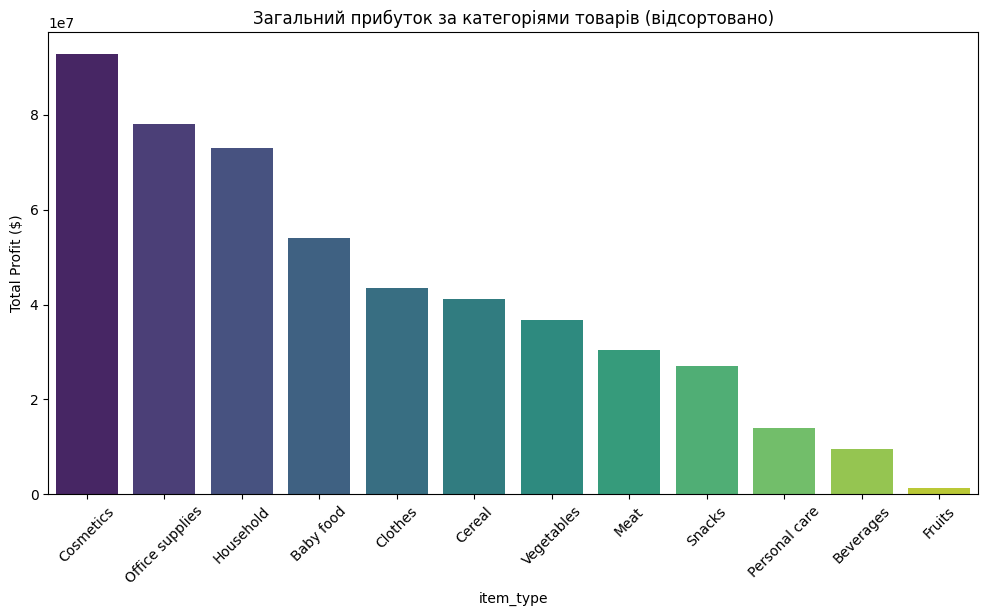

In [ ]:
# 1. Прибуток за категоріями товарів (з сортуванням)
plt.figure(figsize=(12, 6))

# Створюємо відсортований порядок категорій
order = df_full.groupby('item_type')['Total Profit'].sum().sort_values(ascending=False).index

sns.barplot(
    data=df_full,
    x='item_type',
    y='Total Profit',
    estimator=sum,
    palette='viridis',
    order=order,
    errorbar=None # Прибираємо вуса, щоб графік був чистішим
)

plt.title('Загальний прибуток за категоріями товарів (відсортовано)')
plt.xticks(rotation=45)
plt.ylabel('Total Profit ($)')
plt.show()

/tmp/ipykernel_8145/1564102321.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_profit.values, y=region_profit.index, palette='magma')


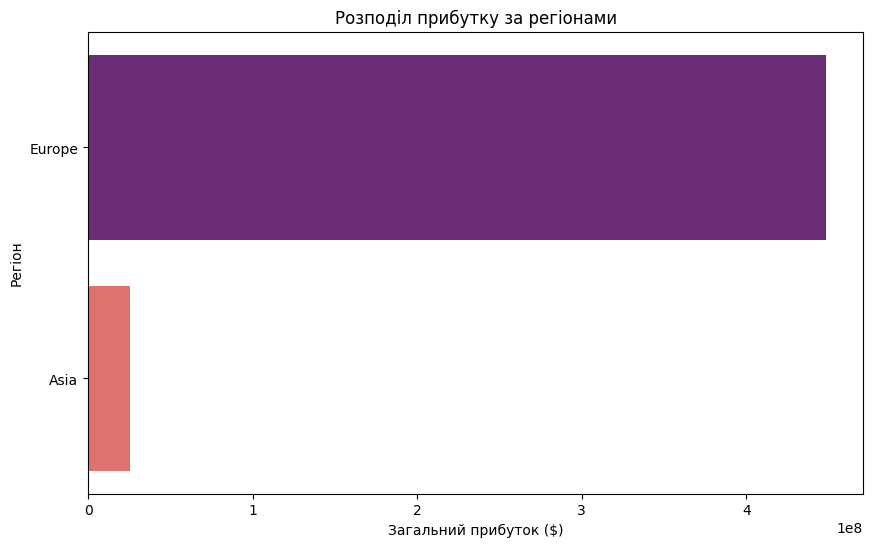

/tmp/ipykernel_8145/1564102321.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')


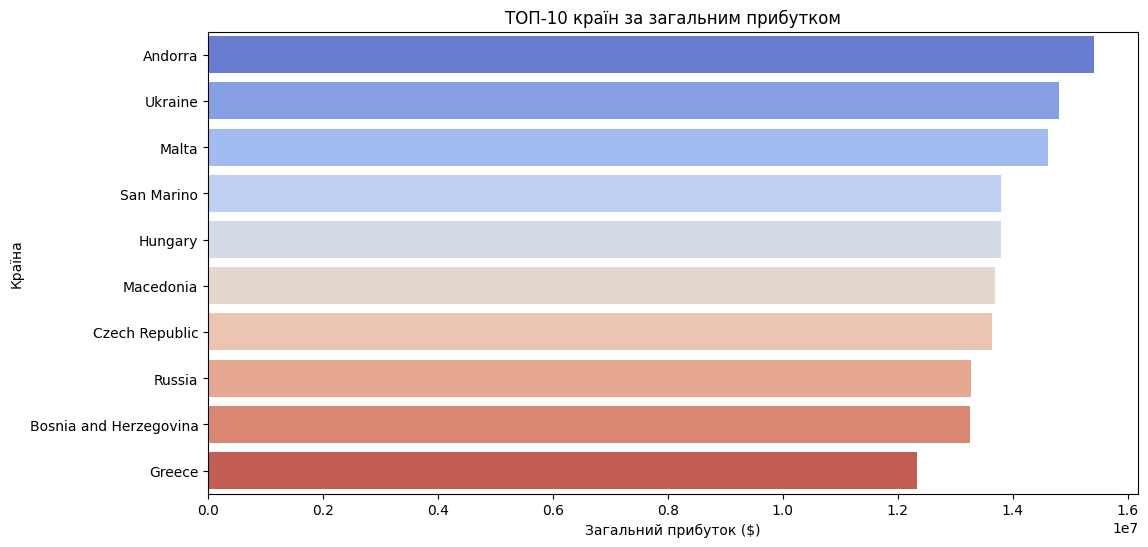

In [ ]:
# 2.1. Прибуток за регіонами
plt.figure(figsize=(10, 6))
region_profit = df_full.groupby('region')['Total Profit'].sum().sort_values(ascending=False)

sns.barplot(x=region_profit.values, y=region_profit.index, palette='magma')
plt.title('Розподіл прибутку за регіонами')
plt.xlabel('Загальний прибуток ($)')
plt.ylabel('Регіон')
plt.show()

# 2.2. ТОП-10 країн за прибутком
plt.figure(figsize=(12, 6))
top_countries = df_full.groupby('name')['Total Profit'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')
plt.title('ТОП-10 країн за загальним прибутком')
plt.xlabel('Загальний прибуток ($)')
plt.ylabel('Країна')
plt.show()

/tmp/ipykernel_8145/460647898.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_full, x='item_type', y='Total Profit', estimator=sum, palette='viridis')


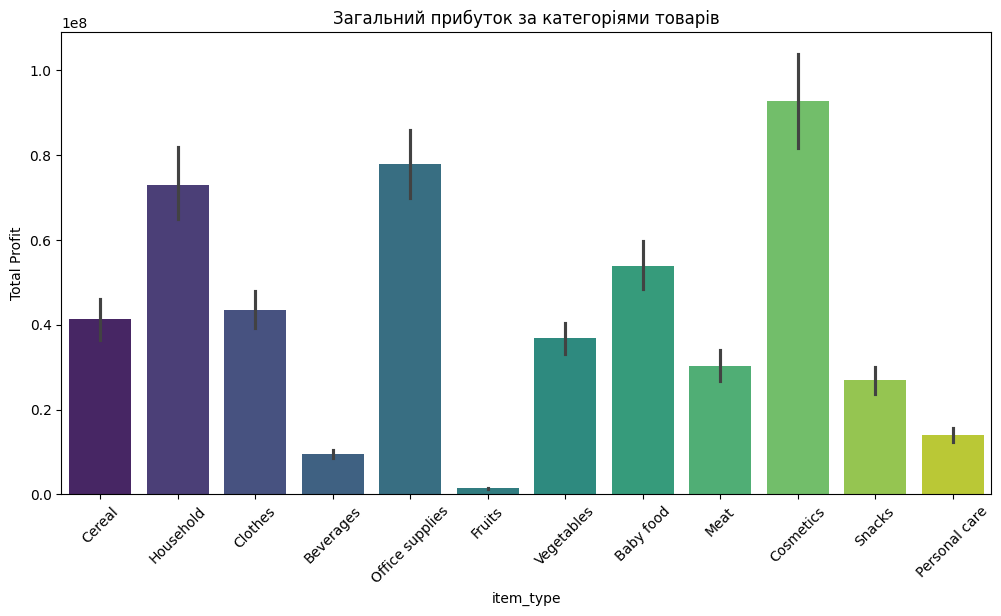

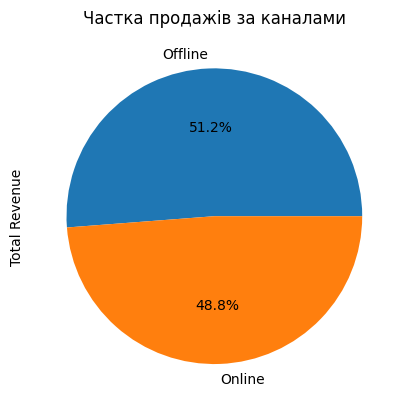

In [ ]:
 # Прибуток за категоріями товарів
plt.figure(figsize=(12, 6))
sns.barplot(data=df_full, x='item_type', y='Total Profit', estimator=sum, palette='viridis')
plt.title('Загальний прибуток за категоріями товарів')
plt.xticks(rotation=45)
plt.show()

# Продажі за каналами (Online vs Offline)
df_full.groupby('Sales Channel')['Total Revenue'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title('Частка продажів за каналами')
plt.show()

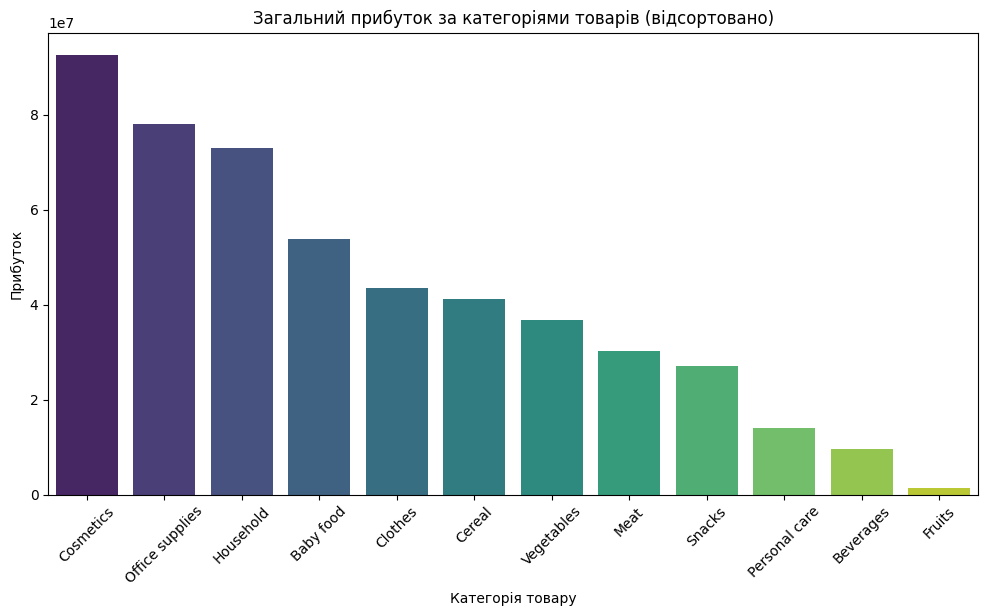

In [ ]:
# 1. Групуємо дані та сортуємо за спаданням прибутку
profit_by_category = df_full.groupby('item_type')['Total Profit'].sum().sort_values(ascending=False).reset_index()

# 2. Будуємо графік
plt.figure(figsize=(12, 6))
sns.barplot(
    data=profit_by_category,
    x='item_type',
    y='Total Profit',
    hue='item_type',  # Додаємо hue, щоб уникнути Warning
    palette='viridis',
    legend=False      # Вимикаємо легенду, бо вона тут дублює вісь X
)

plt.title('Загальний прибуток за категоріями товарів (відсортовано)')
plt.xticks(rotation=45)
plt.ylabel('Прибуток')
plt.xlabel('Категорія товару')
plt.show()

/tmp/ipykernel_8145/7084041.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


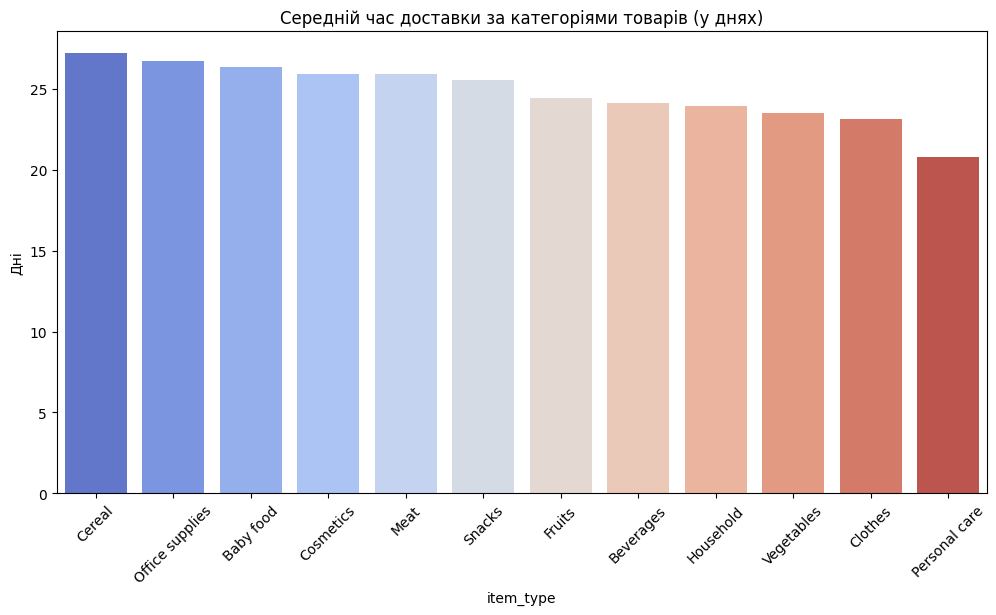

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Сортуємо для кращого вигляду
order = df_full.groupby('item_type')['Delivery Days'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df_full,
    x='item_type',
    y='Delivery Days',
    estimator='mean',
    palette='coolwarm',
    order=order,
    errorbar=None
)

plt.title('Середній час доставки за категоріями товарів (у днях)')
plt.xticks(rotation=45)
plt.ylabel('Дні')
plt.show()

/tmp/ipykernel_8145/3816869151.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


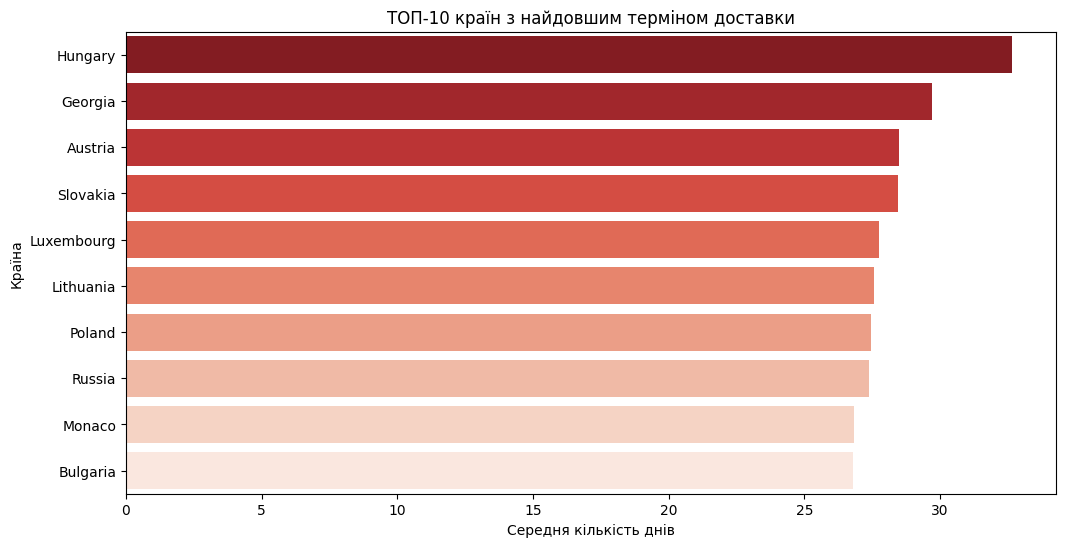

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Беремо ТОП-10 країн з найбільшим часом доставки
top_delivery_countries = df_full.groupby('name')['Delivery Days'].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=top_delivery_countries.values,
    y=top_delivery_countries.index,
    palette='Reds_r'
)

plt.title('ТОП-10 країн з найдовшим терміном доставки')
plt.xlabel('Середня кількість днів')
plt.ylabel('Країна')
plt.show()

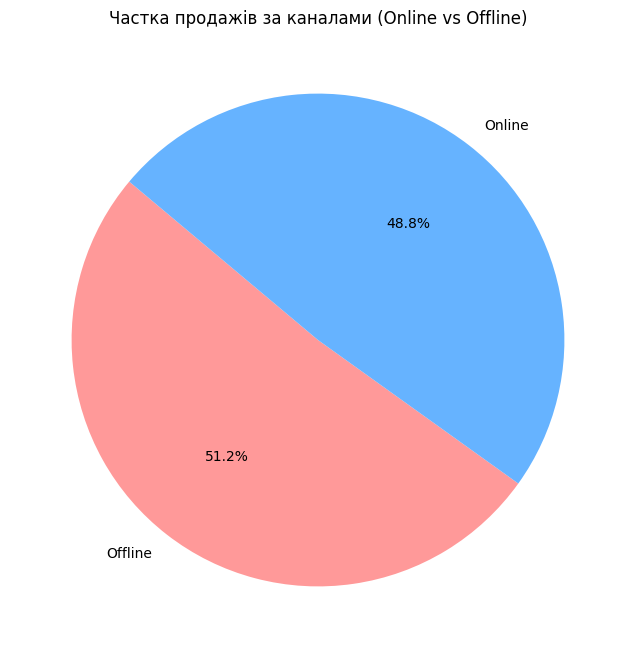

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

df_full.groupby('Sales Channel')['Total Revenue'].sum().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#ff9999','#66b3ff'],
    startangle=140
)

plt.title('Частка продажів за каналами (Online vs Offline)')
plt.ylabel('') # Прибираємо зайвий підпис збоку
plt.show()

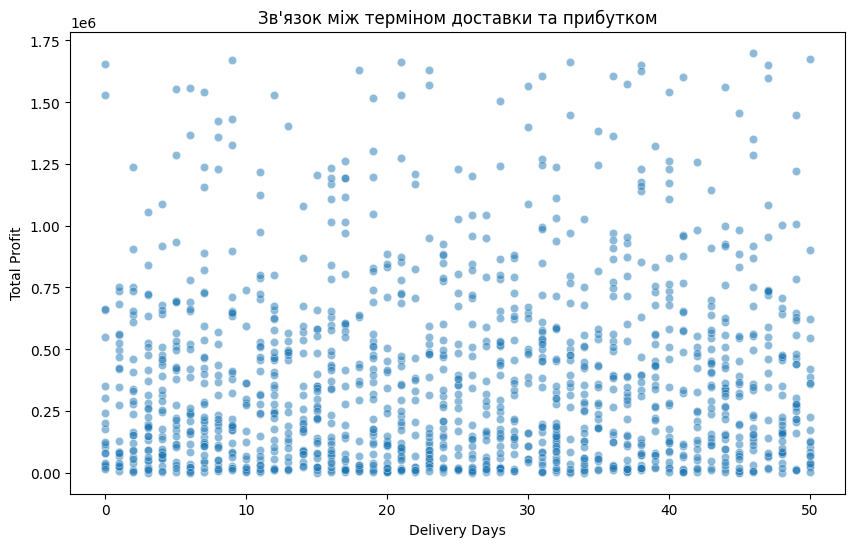

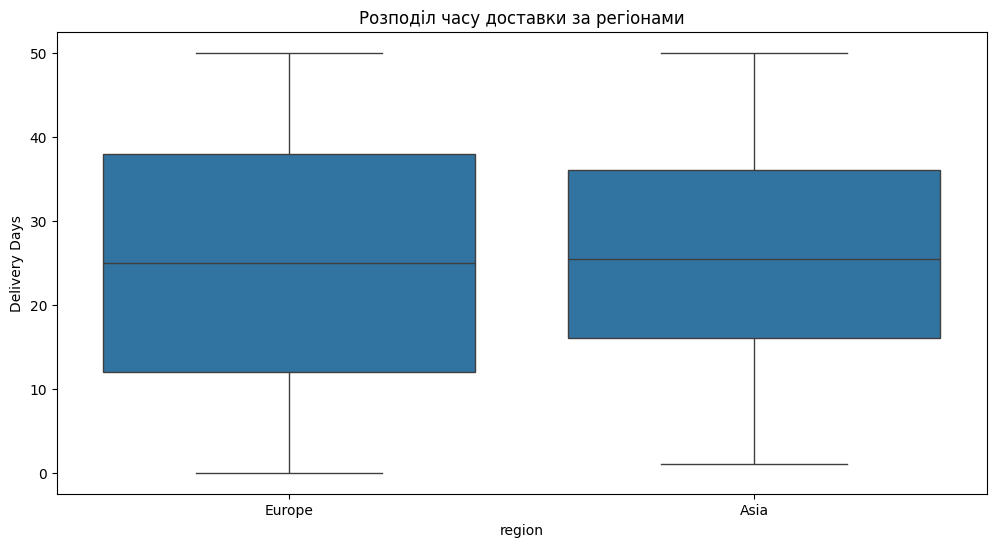

In [ ]:
# Чи залежить прибуток від часу відвантаження?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_full, x='Delivery Days', y='Total Profit', alpha=0.5)
plt.title('Зв\'язок між терміном доставки та прибутком')
plt.show()

# Середня доставка по регіонах
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_full, x='region', y='Delivery Days')
plt.title('Розподіл часу доставки за регіонами')
plt.show()

In [ ]:
# Перетворюємо дату у формат datetime та створюємо колонки для періодів
df_full['Order Date'] = pd.to_datetime(df_full['Order Date'])
df_full['Year_Month'] = df_full['Order Date'].dt.to_period('M').astype(str)
df_full['Month'] = df_full['Order Date'].dt.month

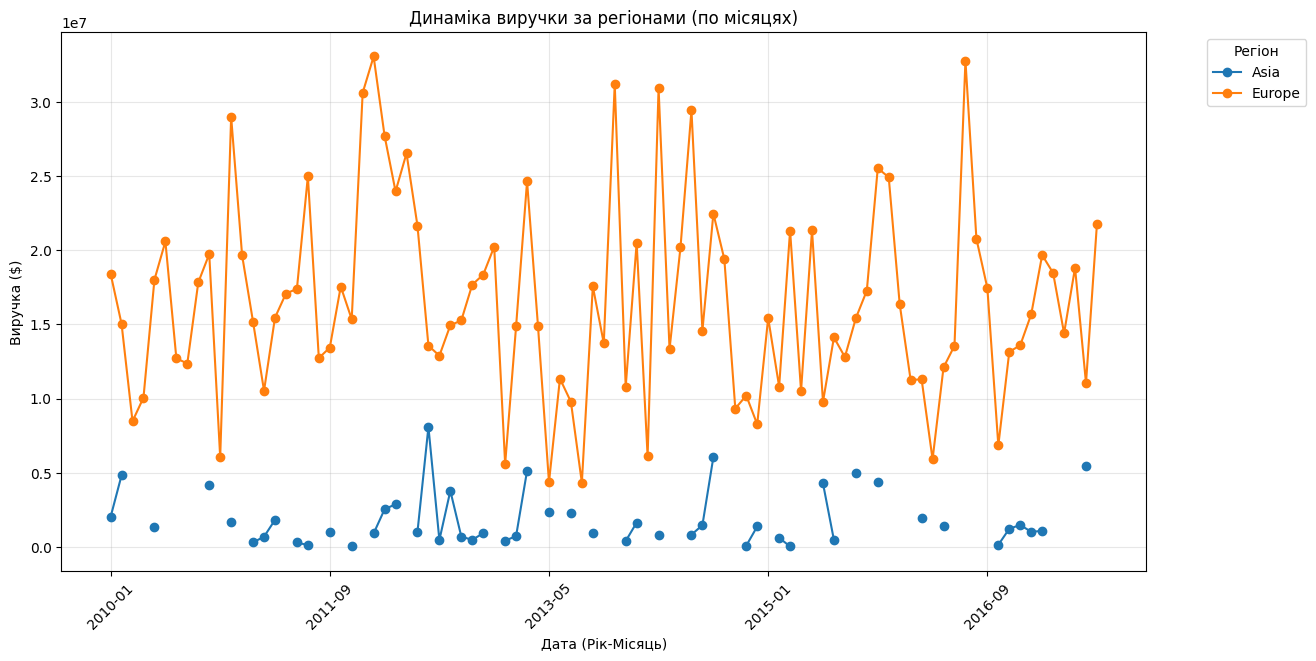

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

# Групуємо за місяцем та регіоном
dynamic_region = df_full.groupby(['Year_Month', 'region'])['Total Revenue'].sum().unstack()

dynamic_region.plot(kind='line', marker='o', ax=plt.gca())

plt.title('Динаміка виручки за регіонами (по місяцях)')
plt.ylabel('Виручка ($)')
plt.xlabel('Дата (Рік-Місяць)')
plt.legend(title='Регіон', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

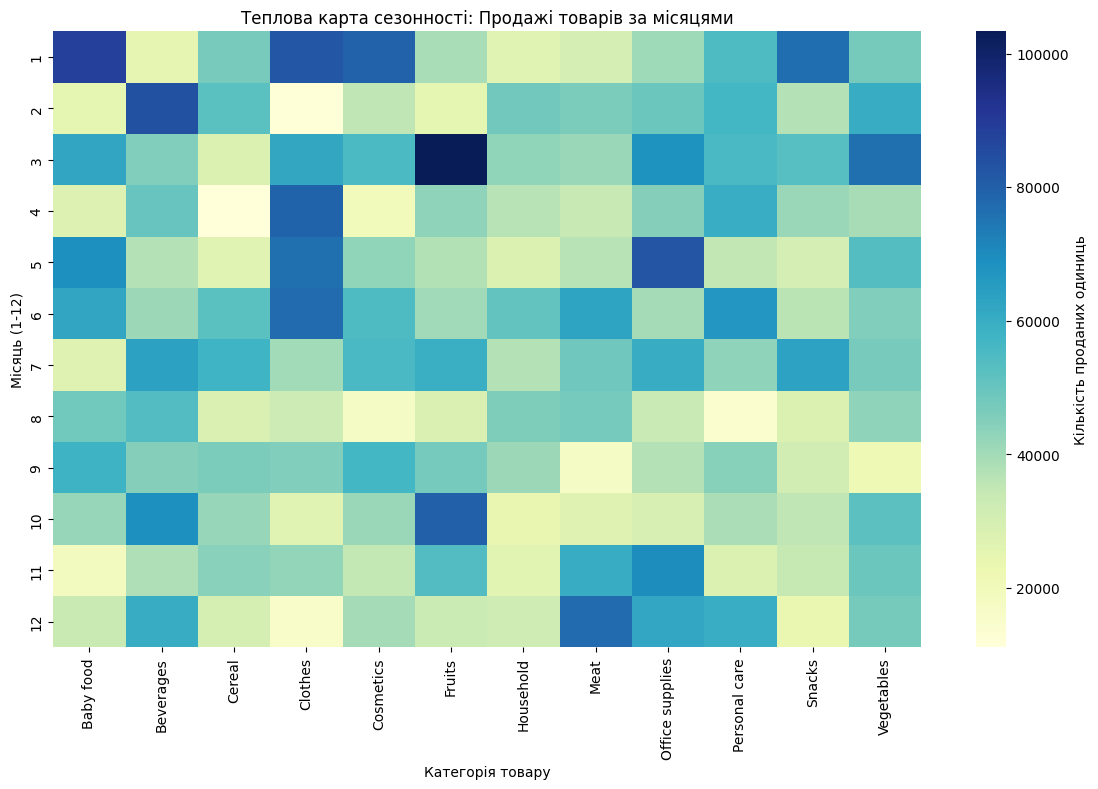

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

# Створюємо зведену таблицю: місяць vs категорія товару
seasonality_data = df_full.pivot_table(
    index='Month',
    columns='item_type',
    values='Units Sold',
    aggfunc='sum'
)

# Візуалізуємо через теплову карту (Heatmap) — це найкращий спосіб побачити сезонність
sns.heatmap(seasonality_data, annot=False, cmap='YlGnBu', cbar_kws={'label': 'Кількість проданих одиниць'})

plt.title('Теплова карта сезонності: Продажі товарів за місяцями')
plt.ylabel('Місяць (1-12)')
plt.xlabel('Категорія товару')
plt.show()

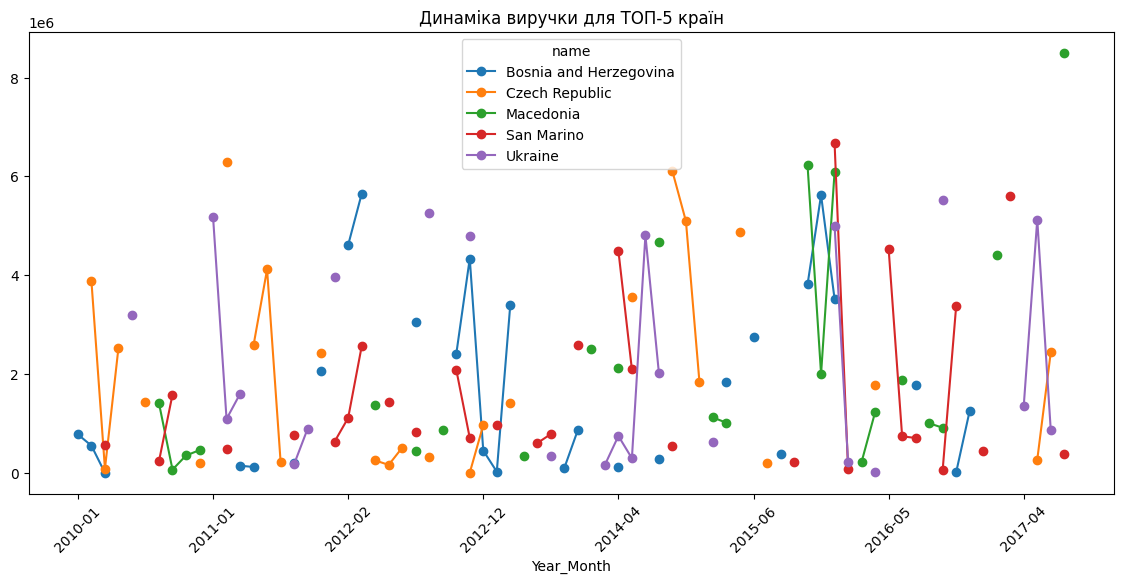

In [ ]:
# Клітинка для динаміки ТОП-5 країн
top_5_countries = df_full.groupby('name')['Total Revenue'].sum().nlargest(5).index
df_top_countries = df_full[df_full['name'].isin(top_5_countries)]

plt.figure(figsize=(14, 6))
df_top_countries.groupby(['Year_Month', 'name'])['Total Revenue'].sum().unstack().plot(marker='o', ax=plt.gca())
plt.title('Динаміка виручки для ТОП-5 країн')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_8145/360392145.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_trend = df_full.set_index('Order Date').resample('M')['Total Profit'].sum()


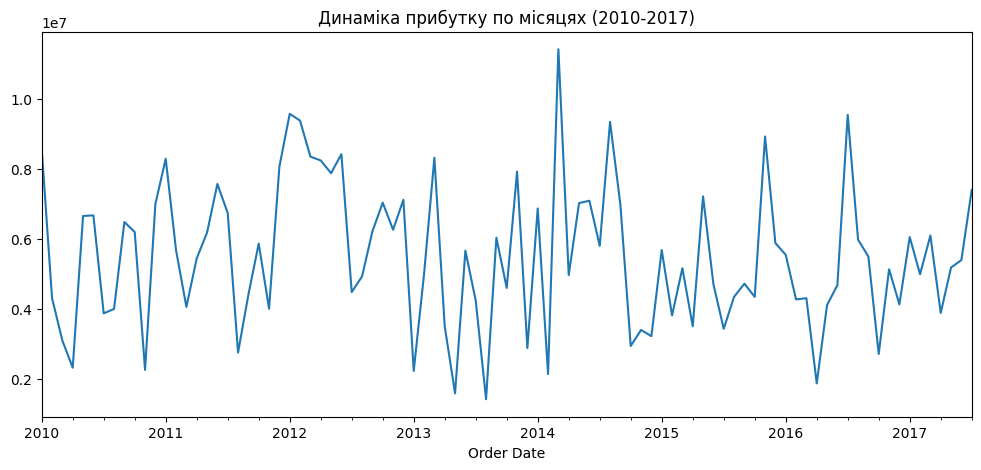

/tmp/ipykernel_8145/360392145.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_full, x='Order Day', order=days_order, palette='magma')


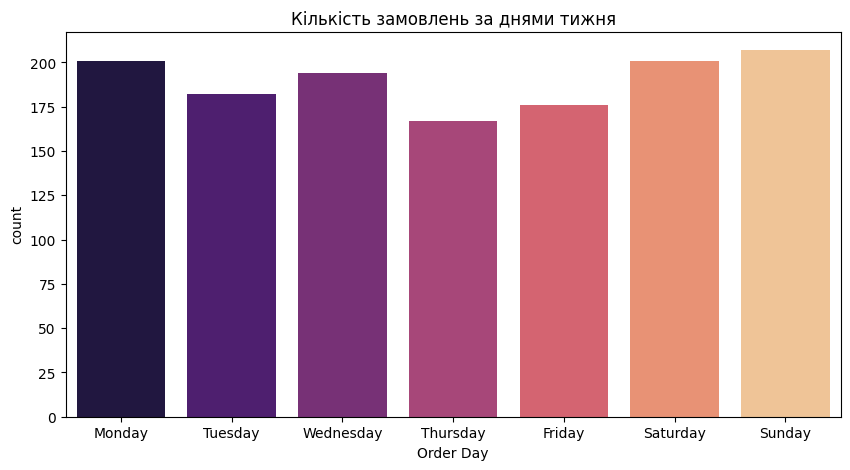

In [ ]:
# Динаміка прибутку по місяцях
df_trend = df_full.set_index('Order Date').resample('M')['Total Profit'].sum()
df_trend.plot(figsize=(12, 5), title='Динаміка прибутку по місяцях (2010-2017)')
plt.show()

# Продажі за днями тижня
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 5))
sns.countplot(data=df_full, x='Order Day', order=days_order, palette='magma')
plt.title('Кількість замовлень за днями тижня')
plt.show()

Висновки: При проведенні комплексного аналізу діяльності компанії, бачимо, що набір даних включає транзакційні записи (events), довідники товарів (products) та регіональну класифікацію (countries). Обсяг вибірки: приблизно 1300 унікальних замовлень. Географія: понад 150 країн у різних регіонах світу.
Основні показники діяльності:
Загальна кількість замовлень: 1328
Загальний прибуток: $501,434,459.00
Кількість охоплених країн: 45
Середній чек: $1,281,723.95
Середній термін доставки: 24.8 дн.
З графіків бачимо, що найприбутковіша категорія: Косметика (Cosmetics) та Офісні товари (Office supplies). Вони складають найбільший сукупний прибуток компанії. Компанія однаково успішно продає товари як Online (48.8%) так і Offline (51.2%). Це свідчить про те, що ми не залежимо від одного каналу.
Графік розсіювання не показує прямої залежності між довгим відвантаженням та втратою прибутку. Це означає, що клієнти готові чекати на товар. В Європі та Азії середній час доставки майже однаковий приблизно 25 днів.
На графіку видно різкі коливання. Піки прибутку спостерігаються щорічно, що підтверджує наявність сезонного попиту, особливо наприкінці року. Найбільша кількість замовлень припадає на неділю та понеділок. Це вказує на те, що клієнтам подобається робити закупи під час вихідних. Аналіз теплової карти показав, що бізнес не має критичної залежності від сезонів року. Проте, спостерігаються специфічні піки попиту для окремих категорій у березні, травні та жовтні.
Рекомендації: пропонується звернути особливу увагу на категорію товарів Fruits, яка є найменш популярна, відповідно приносить малий прибуток, а також потребує окремих умов зберігання та транспортування. Також, період доставки в 25 днів (подекуди до 50 днів) це досить довгий термін, тому варто переглянути встановлені терміни і оцінити, які ж можливі способи пришвидшення термінів доставки. Ще одним рекомендованим способом збільшення кількості продаж є впровадження певних акцій, щоб стимулювати продажі і в будні дні.